<a href="https://colab.research.google.com/github/lidimoura/imersao-dados-python-alura/blob/main/Aulas_Imersao_dados_Python_do_programaONE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aula 1: Introdução e análise Inicial com Pandas

Aula *1* texto em itálico: [acesso YT](https://www.youtube.com/watch?v=x2Bj_ZXf42s)
Introdução e análise de dados com Pandas

In [57]:
import pandas as pd

In [58]:
df = pd.read_csv("https://raw.githubusercontent.com/guilhermeonrails/data-jobs/refs/heads/main/salaries.csv")

In [59]:
df.head(10)

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2025.0,SE,FT,Solutions Engineer,214000,USD,214000,US,100,US,M
1,2025.0,SE,FT,Solutions Engineer,136000,USD,136000,US,100,US,M
2,2025.0,MI,FT,Data Engineer,158800,USD,158800,AU,0,AU,M
3,2025.0,MI,FT,Data Engineer,139200,USD,139200,AU,0,AU,M
4,2025.0,EN,FT,Data Engineer,90000,USD,90000,US,0,US,M
5,2025.0,EN,FT,Data Engineer,80000,USD,80000,US,0,US,M
6,2025.0,SE,FT,Data Scientist,185000,USD,185000,US,0,US,M
7,2025.0,SE,FT,Data Scientist,148000,USD,148000,US,0,US,M
8,2025.0,MI,FT,Data Scientist,135000,USD,135000,CA,0,CA,M
9,2025.0,MI,FT,Data Scientist,108000,USD,108000,CA,0,CA,M


In [60]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 133349 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   work_year           133339 non-null  float64
 1   experience_level    133349 non-null  object 
 2   employment_type     133349 non-null  object 
 3   job_title           133349 non-null  object 
 4   salary              133349 non-null  int64  
 5   salary_currency     133349 non-null  object 
 6   salary_in_usd       133349 non-null  int64  
 7   employee_residence  133349 non-null  object 
 8   remote_ratio        133349 non-null  int64  
 9   company_location    133349 non-null  object 
 10  company_size        133349 non-null  object 
dtypes: float64(1), int64(3), object(7)
memory usage: 11.2+ MB


In [61]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,133339.000000,1.333490e+05,133349.000000,133349.000000
mean,2024.358770,1.632833e+05,157617.272098,20.905669
std,0.680627,2.173860e+05,74288.363097,40.590044
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,1.060200e+05,106000.000000,0.000000
50%,2024.000000,1.470000e+05,146206.000000,0.000000
75%,2025.000000,1.990000e+05,198000.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [62]:
df.shape

(133349, 11)

In [63]:
linhas, colunas = df.shape [0], df.shape[1]
print("linhas", linhas)
print("colunas", colunas)

linhas 133349
colunas 11


In [64]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size'],
      dtype='object')

In [65]:
# Dicionário para mapear os nomes das colunas para português
traducao_colunas = {
    'work_year': 'ano_trabalho',
    'experience_level': 'senoriedade', # Corrigindo o erro de digitação
    'employment_type': 'tipo_emprego',
    'job_title': 'cargo',
    'salary': 'salario',
    'salary_currency': 'moeda_salario',
    'salary_in_usd': 'salario_em_usd',
    'employee_residence': 'residencia_empregado',
    'remote_ratio': 'taxa_remoto',
    'company_location': 'localizacao_empresa',
    'company_size': 'tamanho_empresa'
}

# Renomear as colunas do DataFrame
df = df.rename(columns=traducao_colunas)

# Exibir os novos nomes das colunas para verificar a tradução
print(df.columns)

Index(['ano_trabalho', 'senoriedade', 'tipo_emprego', 'cargo', 'salario',
       'moeda_salario', 'salario_em_usd', 'residencia_empregado',
       'taxa_remoto', 'localizacao_empresa', 'tamanho_empresa'],
      dtype='object')


In [66]:
# Corrigir o nome da coluna de 'senoriedade' para 'senoridade'
df = df.rename(columns={'senoriedade': 'senoridade'})

# Exibir os nomes das colunas para verificar a correção
print(df.columns)

Index(['ano_trabalho', 'senoridade', 'tipo_emprego', 'cargo', 'salario',
       'moeda_salario', 'salario_em_usd', 'residencia_empregado',
       'taxa_remoto', 'localizacao_empresa', 'tamanho_empresa'],
      dtype='object')


In [67]:
df["senoridade"].value_counts() # Atualizando para o nome da coluna corrigido

,count
senoridade,
SE,77241
MI,40465
EN,12443
EX,3200


In [68]:
df["tipo_emprego"].value_counts()

,count
tipo_emprego,
FT,132563
CT,394
PT,376
FL,16


In [69]:
df["taxa_remoto"].value_counts()

,count
taxa_remoto,
0,105312
100,27718
50,319


In [70]:
df["tamanho_empresa"].value_counts()

,count
tamanho_empresa,
M,129561
L,3574
S,214


In [71]:
# Dicionário para mapear as categorias para português
senoridade = {
    'SE': 'Senior',
    'MI': 'Pleno',
    'EN': 'Junior',
    'EX': 'Executivo'
}

# Traduzir as categorias na coluna 'senoridade'
df['senoridade'] = df['senoridade'].replace(senoridade)

# Exibir as contagens de valores para verificar a tradução
print(df['senoridade'].value_counts())

senoridade
Senior       77241
Pleno        40465
Junior       12443
Executivo     3200
Name: count, dtype: int64


In [72]:
# Dicionário para mapear as categorias do masculino para o feminino em português
traducao_genero_tamanho_empresa = {
    'Médio': 'Média',
    'Pequeno': 'Pequena'
}

# Traduzir as categorias na coluna 'tamanho_empresa'
df['tamanho_empresa'] = df['tamanho_empresa'].replace(traducao_genero_tamanho_empresa)

# Exibir as contagens de valores para verificar a tradução
print(df['tamanho_empresa'].value_counts())

tamanho_empresa
M    129561
L      3574
S       214
Name: count, dtype: int64


In [73]:
# Dicionário para mapear as categorias para português
traducao_categorias_remoto = {
    0: 'Presencial',
    50: 'Híbrido',
    100: 'Remoto'
}

# Traduzir as categorias na coluna 'remoto'
df['taxa_remoto'] = df['taxa_remoto'].replace(traducao_categorias_remoto)

# Exibir as contagens de valores para verificar a tradução
print(df['taxa_remoto'].value_counts())

taxa_remoto
Presencial    105312
Remoto         27718
Híbrido          319
Name: count, dtype: int64


In [74]:
df.head()

,ano_trabalho,senoridade,tipo_emprego,cargo,salario,moeda_salario,salario_em_usd,residencia_empregado,taxa_remoto,localizacao_empresa,tamanho_empresa
0,2025.0,Senior,FT,Solutions Engineer,214000,USD,214000,US,Remoto,US,M
1,2025.0,Senior,FT,Solutions Engineer,136000,USD,136000,US,Remoto,US,M
2,2025.0,Pleno,FT,Data Engineer,158800,USD,158800,AU,Presencial,AU,M
3,2025.0,Pleno,FT,Data Engineer,139200,USD,139200,AU,Presencial,AU,M
4,2025.0,Junior,FT,Data Engineer,90000,USD,90000,US,Presencial,US,M


In [75]:
df.describe(include="object")

,senoridade,tipo_emprego,cargo,moeda_salario,residencia_empregado,taxa_remoto,localizacao_empresa,tamanho_empresa
count,133349,133349,133349,133349,133349,133349,133349,133349
unique,4,4,390,26,102,3,95,3
top,Senior,FT,Data Scientist,USD,US,Presencial,US,M
freq,77241,132563,17314,126140,119579,105312,119641,129561


In [76]:
df.describe()

,ano_trabalho,salario,salario_em_usd
count,133339.000000,1.333490e+05,133349.000000
mean,2024.358770,1.632833e+05,157617.272098
std,0.680627,2.173860e+05,74288.363097
min,2020.000000,1.400000e+04,15000.000000
25%,2024.000000,1.060200e+05,106000.000000
50%,2024.000000,1.470000e+05,146206.000000
75%,2025.000000,1.990000e+05,198000.000000
max,2025.000000,3.040000e+07,800000.000000


# Aula 2: Limpeza e Análise Exploratória

In [77]:
df.isnull()

,ano_trabalho,senoridade,tipo_emprego,cargo,salario,moeda_salario,salario_em_usd,residencia_empregado,taxa_remoto,localizacao_empresa,tamanho_empresa
0,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...
133344,False,False,False,False,False,False,False,False,False,False,False
133345,False,False,False,False,False,False,False,False,False,False,False
133346,False,False,False,False,False,False,False,False,False,False,False
133347,False,False,False,False,False,False,False,False,False,False,False


In [78]:
df.head()

,ano_trabalho,senoridade,tipo_emprego,cargo,salario,moeda_salario,salario_em_usd,residencia_empregado,taxa_remoto,localizacao_empresa,tamanho_empresa
0,2025.0,Senior,FT,Solutions Engineer,214000,USD,214000,US,Remoto,US,M
1,2025.0,Senior,FT,Solutions Engineer,136000,USD,136000,US,Remoto,US,M
2,2025.0,Pleno,FT,Data Engineer,158800,USD,158800,AU,Presencial,AU,M
3,2025.0,Pleno,FT,Data Engineer,139200,USD,139200,AU,Presencial,AU,M
4,2025.0,Junior,FT,Data Engineer,90000,USD,90000,US,Presencial,US,M


In [79]:
df.isnull().sum()

,0
ano_trabalho,10
senoridade,0
tipo_emprego,0
cargo,0
salario,0
moeda_salario,0
salario_em_usd,0
residencia_empregado,0
taxa_remoto,0
localizacao_empresa,0


In [80]:
df["ano_trabalho"].unique()

array([2025.,   nan, 2024., 2022., 2023., 2020., 2021.])

In [81]:
df[df.isnull().any(axis=1)]

,ano_trabalho,senoridade,tipo_emprego,cargo,salario,moeda_salario,salario_em_usd,residencia_empregado,taxa_remoto,localizacao_empresa,tamanho_empresa
5588,NaN,Senior,FT,Product Manager,184500,USD,184500,US,Presencial,US,M
59692,NaN,Pleno,FT,Engineer,110000,USD,110000,DE,Presencial,DE,M
59710,NaN,Junior,FT,Data Scientist,208800,USD,208800,US,Presencial,US,M
59759,NaN,Senior,FT,Software Engineer,135000,USD,135000,US,Presencial,US,M
59789,NaN,Senior,FT,Engineer,112000,USD,112000,US,Presencial,US,M
131000,NaN,Senior,FT,Machine Learning Engineer,163800,USD,163800,US,Presencial,US,M
131006,NaN,Senior,FT,Data Analytics Manager,204500,USD,204500,US,Presencial,US,M
133054,NaN,Junior,FT,Data Scientist,40000,USD,40000,JP,Remoto,MY,L
133281,NaN,Pleno,FT,Machine Learning Engineer,180000,PLN,46597,PL,Remoto,PL,L
133317,NaN,Pleno,FT,Data Scientist,130000,USD,130000,US,Híbrido,US,L


In [82]:
#Vamos criar um novo dataFrame do zero, e vamos nomear para df_salarios -> como um possibilidade para resolver esses valores que estão nulos

import numpy as np

# importamos essa biblioteca para manipular dados not a number/null

df_salarios = pd.DataFrame({
    'nome': ["Ana", "Bruno", "Carlos", "Daniele", "Val"],
    'salario': [4000, np.nan, 5000, np.nan, 1000000]
                         })
#calcula a média salarial e substitui os nulos pela média e arredonda os valores
df_salarios['salario_media'] = df_salarios['salario'].fillna(df_salarios['salario'].mean().round(2))

# Calcula a mediana salarial e substitui os nulos pela mediana e arredonda os valores

df_salarios['salario_mediana'] = df_salarios['salario'].fillna(df_salarios['salario'].median())
# usamos a mediana pq ela suaviza o impacto das diferenças
df_salarios


,nome,salario,salario_media,salario_mediana
0,Ana,4000.0,4000.00,4000.0
1,Bruno,NaN,336333.33,5000.0
2,Carlos,5000.0,5000.00,5000.0
3,Daniele,NaN,336333.33,5000.0
4,Val,1000000.0,1000000.00,1000000.0


In [83]:
#Agora com temperaturas vamos usar outra estratégia ffill - forward fill - preencher com o que veio antes
df_temperaturas = pd.DataFrame({
    "Dia": ["Segunda", "Terça", "Quarta", "Quinta", "Sexta"],
    "Temperatura": [30, np.nan, np.nan, 28, 27]
})

df_temperaturas["Preenchido_ffill"] = df_temperaturas["Temperatura"].ffill()
df_temperaturas

,Dia,Temperatura,Preenchido_ffill
0,Segunda,30.0,30.0
1,Terça,NaN,30.0
2,Quarta,NaN,30.0
3,Quinta,28.0,28.0
4,Sexta,27.0,27.0


In [84]:
#Outra estrategia com bfill - backfill
df_temperaturas = pd.DataFrame({
    "Dia": ["Segunda", "Terça", "Quarta", "Quinta", "Sexta"],
    "Temperatura": [30, np.nan, np.nan, 28, 27]
})

df_temperaturas["Preenchido_bfill"] = df_temperaturas["Temperatura"].bfill()
df_temperaturas

,Dia,Temperatura,Preenchido_bfill
0,Segunda,30.0,30.0
1,Terça,NaN,28.0
2,Quarta,NaN,28.0
3,Quinta,28.0,28.0
4,Sexta,27.0,27.0


In [85]:
df_cidades = pd.DataFrame({
    'nome': ["Ana", "Bruno", "Carlos", "Daniele", "Val"],
    'cidade': ["São Paulo", np.nan, "Curitiba", np.nan, "Belém"]
    })

df_cidades['cidade_preenchida'] = df_cidades["cidade"].fillna("Não informado") # Corrigido: Usando [] para criar nova coluna
df_cidades

,nome,cidade,cidade_preenchida
0,Ana,São Paulo,São Paulo
1,Bruno,NaN,Não informado
2,Carlos,Curitiba,Curitiba
3,Daniele,NaN,Não informado
4,Val,Belém,Belém


In [86]:
df_limpo = df.dropna()

# Dicionário para mapear as categorias para português
senoridade_traduzido = {
    'SE': 'Senior',
    'MI': 'Pleno',
    'EN': 'Junior',
    'EX': 'Executivo'
}

# Traduzir as categorias na coluna 'senoridade'
df_limpo['senoridade'] = df_limpo['senoridade'].replace(senoridade_traduzido)

# Dicionário para mapear as categorias para português
traducao_categorias_remoto = {
    0: 'Presencial',
    50: 'Híbrido',
    100: 'Remoto'
}

# Traduzir as categorias na coluna 'remoto'
df_limpo['taxa_remoto'] = df_limpo['taxa_remoto'].replace(traducao_categorias_remoto)


# Dicionário para mapear as categorias do tamanho da empresa para português
tamanho_empresa_traduzido = {
    'M': 'Média',
    'S': 'Pequena',
    'L': 'Grande'
}

# Traduzir as categorias na coluna 'tamanho_empresa'
df_limpo['tamanho_empresa'] = df_limpo['tamanho_empresa'].replace(tamanho_empresa_traduzido)

# Dicionário para renomear as colunas
novos_nomes_colunas = {
    'ano_trabalho': 'ano',
    'tipo_emprego': 'contrato',
    'moeda_salario': 'moeda',
    'salario_em_usd': 'usd',
    'residencia_empregado': 'residencia',
    'taxa_remoto': 'remoto',
    'localizacao_empresa': 'empresa'
}

# Renomear as colunas
df_limpo = df_limpo.rename(columns=novos_nomes_colunas)

/tmp/ipykernel_19994/3351307032.py:12: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_19994/3351307032.py:22: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_19994/3351307032.py:33: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [87]:
df_limpo.isnull().sum()

,0
ano,0
senoridade,0
contrato,0
cargo,0
salario,0
moeda,0
usd,0
residencia,0
remoto,0
empresa,0


In [88]:
df_limpo.head()

,ano,senoridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025.0,Senior,FT,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025.0,Senior,FT,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025.0,Pleno,FT,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025.0,Pleno,FT,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025.0,Junior,FT,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [89]:
df_limpo.info()

<class 'pandas.core.frame.DataFrame'>
Index: 133339 entries, 0 to 133348
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ano              133339 non-null  float64
 1   senoridade       133339 non-null  object 
 2   contrato         133339 non-null  object 
 3   cargo            133339 non-null  object 
 4   salario          133339 non-null  int64  
 5   moeda            133339 non-null  object 
 6   usd              133339 non-null  int64  
 7   residencia       133339 non-null  object 
 8   remoto           133339 non-null  object 
 9   empresa          133339 non-null  object 
 10  tamanho_empresa  133339 non-null  object 
dtypes: float64(1), int64(2), object(8)
memory usage: 12.2+ MB


In [90]:
df_limpo = df_limpo.assign(ano = df_limpo['ano'].astype('int64'))

# Aula 3: Visualização de Dados
Crie gráficos e conte história com dados

In [91]:
df_limpo.head()

,ano,senoridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,Senior,FT,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025,Senior,FT,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025,Pleno,FT,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025,Pleno,FT,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025,Junior,FT,Data Engineer,90000,USD,90000,US,Presencial,US,Média


<Axes: title={'center': 'Distribuição de senoridade'}, xlabel='senoridade'>

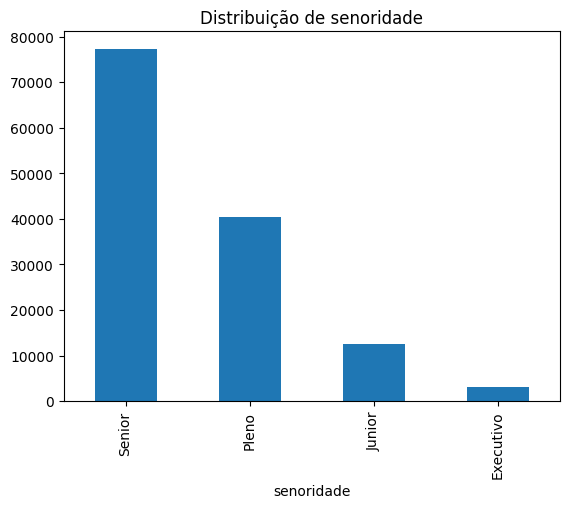

In [92]:
df_limpo['senoridade'].value_counts().plot(kind='bar', title='Distribuição de senoridade')

In [93]:
import seaborn as sns

<Axes: xlabel='senoridade', ylabel='usd'>

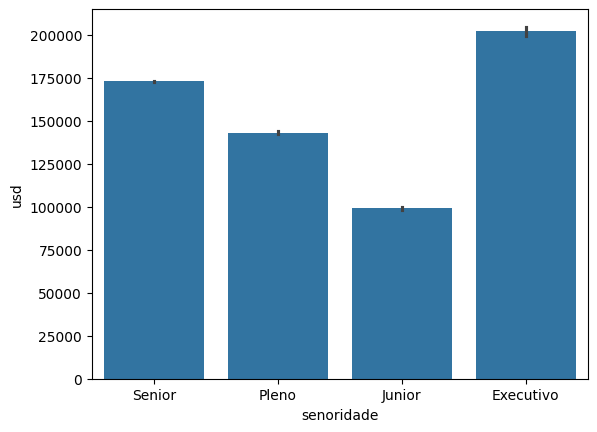

In [94]:
sns.barplot(data=df_limpo, x='senoridade', y='usd')

In [95]:
import matplotlib.pyplot as plt

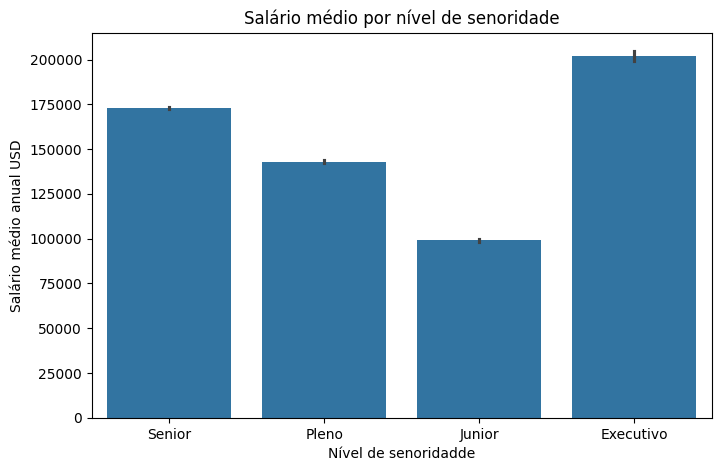

In [96]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_limpo, x='senoridade', y='usd')
plt.title("Salário médio por nível de senoridade")
plt.xlabel("Nível de senoridadde")
plt.ylabel("Salário médio anual USD")
plt.show()

In [97]:
df_limpo.groupby('senoridade')['usd'].mean().sort_values(ascending=False)

,usd
senoridade,
Executivo,202027.667813
Senior,172850.838301
Pleno,143044.845979
Junior,99034.963267


In [98]:
ordem = df_limpo.groupby('senoridade')['usd'].mean().sort_values(ascending=True).index
ordem

Index(['Junior', 'Pleno', 'Senior', 'Executivo'], dtype='object', name='senoridade')

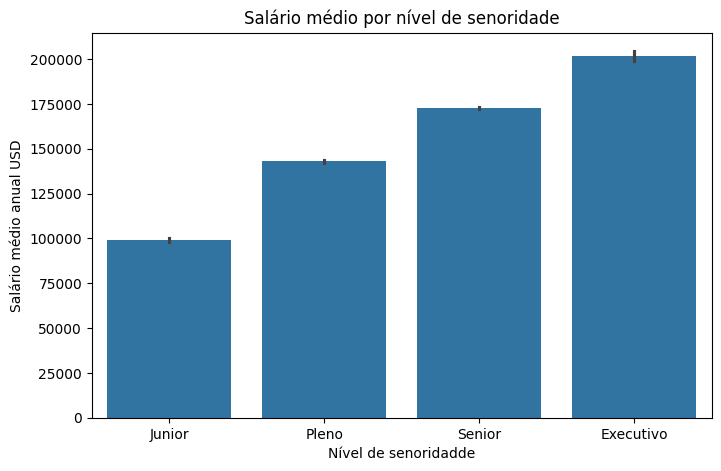

In [99]:
plt.figure(figsize=(8, 5))
sns.barplot(data=df_limpo, x='senoridade', y='usd', order=ordem)
plt.title("Salário médio por nível de senoridade")
plt.xlabel("Nível de senoridadde")
plt.ylabel("Salário médio anual USD")
plt.show()

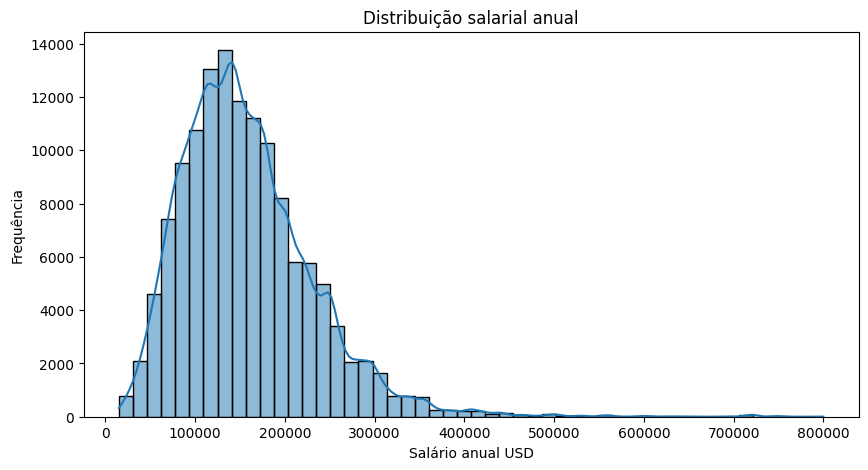

In [100]:
plt.figure(figsize=(10, 5))
sns.histplot(df_limpo['usd'], bins=50, kde=True)
plt.title("Distribuição salarial anual")
plt.xlabel("Salário anual USD")
plt.ylabel("Frequência")
plt.show()

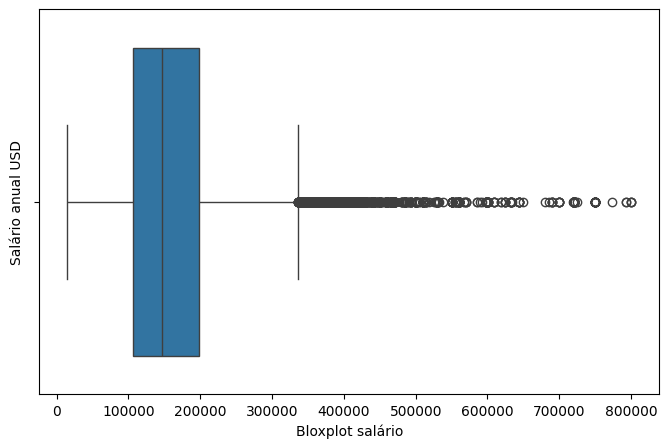

In [101]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_limpo['usd'])
plt.xlabel("Bloxplot salário")
plt.ylabel("Salário anual USD")
plt.show()
#para mostrar a distribuição dentro de uma caixa com variancias, qual o valor minimo e maximo com uma linha no meio que representa a mediana

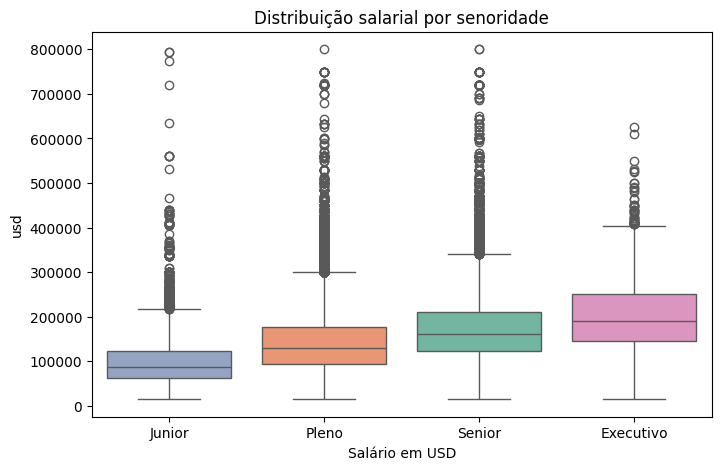

In [102]:
ordem_senoridade = ['Junior', 'Pleno', 'Senior', 'Executivo']
plt.figure(figsize=(8, 5))
sns.boxplot(x='senoridade', y='usd', data=df_limpo, order=ordem_senoridade, palette='Set2', hue='senoridade')
plt.title("Distribuição salarial por senoridade")
plt.xlabel('Salário em USD')
plt.show()

In [103]:
import plotly.express  as px

In [104]:
salario_medio_por_senoridade = df_limpo.groupby('senoridade')['usd'].mean().sort_values(ascending=False).reset_index()


fig = px.bar(salario_medio_por_senoridade,
             x='senoridade',
             y='usd',
             title='Salário Médio por Nível de Senoridade (Plotly)',
             labels={'senoridade': 'Nível de Senoridade', 'usd': 'Salário Médio Anual (USD)'})


fig.show()

In [105]:
remoto_contagem = df_limpo['remoto'].value_counts().reset_index()
remoto_contagem.columns = ['tipo_trabalho', 'quantidade']

fig = px.pie(remoto_contagem,
             names='tipo_trabalho',
             values='quantidade',
             title='Proporção dos tipos de trabalho',
             hole=0.3
             )

fig.update_traces(textinfo='percent+label')
fig.show()

In [106]:
df_ds = df_limpo[df_limpo['cargo'].str.contains('Data Scientist', case=False, na=False)]

salario_por_pais = df_ds.groupby('residencia')['usd'].mean().reset_index()

salario_por_pais = salario_por_pais.sort_values(by='usd', ascending=False)

fig_bar = px.bar(
    salario_por_pais,
    x='residencia',
    y='usd',
    text='usd',
    title='Salário Médio de Data Science por País (USD)',
    labels={'usd': 'Salário Médio (USD)', 'residencia': 'País'}
)

fig_bar.update_traces(texttemplate='%{text:.2f}', textposition='outside')
fig_bar.update_layout(xaxis_tickangle=-90)
fig_bar.show()

In [107]:
df_limpo.head()

,ano,senoridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa
0,2025,Senior,FT,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média
1,2025,Senior,FT,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média
2,2025,Pleno,FT,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média
3,2025,Pleno,FT,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média
4,2025,Junior,FT,Data Engineer,90000,USD,90000,US,Presencial,US,Média


In [108]:
pip install pycountry

In [109]:
import pycountry

#Função para converter ISO-2 para ISO-3
def iso2_to_iso3(code):
  try:
    return pycountry.countries.get(alpha_2=code).alpha_3
  except AttributeError:
    return None

# Criar nova coluna com código ISO-3
df_limpo['residencia_iso3'] = df_limpo['residencia'].apply(iso2_to_iso3)

#Calcular média salarial por país (ISO-3)
df_ds = df_limpo[df_limpo['cargo'] == 'Data Scientist']
media_ds_pais = df_ds.groupby('residencia_iso3')['usd'].mean().reset_index()

#Gerar o mapa
fig = px.choropleth(media_ds_pais,
                    locations='residencia_iso3',
                    color='usd',
                    color_continuous_scale='rdylgn',
                    title='Salário médio de Cientista de dados por país',
                    labels={'usd': 'Salário médio (USD)', 'residencia_iso3': 'País'})

fig.show()

In [110]:
df_limpo.head()

,ano,senoridade,contrato,cargo,salario,moeda,usd,residencia,remoto,empresa,tamanho_empresa,residencia_iso3
0,2025,Senior,FT,Solutions Engineer,214000,USD,214000,US,Remoto,US,Média,USA
1,2025,Senior,FT,Solutions Engineer,136000,USD,136000,US,Remoto,US,Média,USA
2,2025,Pleno,FT,Data Engineer,158800,USD,158800,AU,Presencial,AU,Média,AUS
3,2025,Pleno,FT,Data Engineer,139200,USD,139200,AU,Presencial,AU,Média,AUS
4,2025,Junior,FT,Data Engineer,90000,USD,90000,US,Presencial,US,Média,USA


In [112]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

# 1. Criar pasta de assets
if not os.path.exists('assets'):
    os.makedirs('assets')

# 2. Gráfico de Distribuição de Salários
plt.figure(figsize=(10, 6))
sns.histplot(df_limpo['usd'], kde=True, color='blue')
plt.title('Distribuição de Salários em USD')
plt.xlabel('Salário Anual (USD)')
plt.ylabel('Frequência')
plt.savefig('assets/grafico_distribuicao_salarios.png', bbox_inches='tight')
plt.close()

# 3. Gráfico de Salário Médio por Senioridade (usando sua coluna corrigida!)
plt.figure(figsize=(10, 6))
df_limpo.groupby('senoridade')['usd'].mean().sort_values().plot(kind='barh', color='orange')
plt.title('Média Salarial por Senioridade')
plt.xlabel('Salário Médio (USD)')
plt.ylabel('Senioridade')
plt.savefig('assets/grafico_top_10_cargos.png', bbox_inches='tight') # Usando o nome que está no seu README
plt.close()

# 4. Proporção de Modelos de Trabalho (Remote Ratio)
plt.figure(figsize=(8, 8))
df_limpo['remoto'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['skyblue', 'lightgreen', 'salmon'])
plt.title('Proporção de Modelos de Trabalho')
plt.ylabel('')
plt.savefig('assets/grafico_tipo_trabalho.png', bbox_inches='tight')
plt.close()

print("✅ Gráficos gerados com sucesso na pasta /assets!")

✅ Gráficos gerados com sucesso na pasta /assets!


In [113]:
df_limpo.to_csv('dados-imersao-final.csv', index=False)